In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
weather = pd.read_csv("../data/GlobalWeatherRepository.csv")
tourism = pd.read_csv("../data/international-tourist-trips.csv")

In [13]:
print(weather.head())
print(tourism.head())

       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
0                    79.8  Partly Cloudy  ...                8.4   
1                    66.2  Partly cloudy

In [16]:
print(weather.columns)
print(tourism.columns)

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')
Index(['Entity', 'Code', 'Year', 'Arrivals of tourists from abroad'], dtype='object')


In [20]:
print(weather.describe())

            latitude      longitude  last_updated_epoch  temperature_celsius  \
count  128833.000000  128833.000000        1.288330e+05        128833.000000   
mean       19.201670      21.981068        1.744516e+09            21.442119   
std        24.421259      65.789383        1.653923e+07             9.676936   
min       -41.300000    -175.200000        1.715849e+09           -29.800000   
25%         3.750000      -6.836100        1.730192e+09            16.200000   
50%        17.250000      23.236100        1.744535e+09            24.100000   
75%        40.400000      50.580000        1.758786e+09            28.000000   
max        64.150000     179.220000        1.773211e+09            49.200000   

       temperature_fahrenheit       wind_mph       wind_kph    wind_degree  \
count           128833.000000  128833.000000  128833.000000  128833.000000   
mean                70.597606       8.048181      12.955899     169.035519   
std                 17.418354       7.314118 

In [21]:
print(tourism.head())

    Entity Code  Year  Arrivals of tourists from abroad
0  Albania  ALB  2007                         1062000.0
1  Albania  ALB  2008                         1247000.0
2  Albania  ALB  2009                         1711000.0
3  Albania  ALB  2010                         2191000.0
4  Albania  ALB  2011                         2469000.0


In [26]:
print(weather.info())
print(tourism.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128833 entries, 0 to 128832
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       128833 non-null  object 
 1   location_name                 128833 non-null  object 
 2   latitude                      128833 non-null  float64
 3   longitude                     128833 non-null  float64
 4   timezone                      128833 non-null  object 
 5   last_updated_epoch            128833 non-null  int64  
 6   last_updated                  128833 non-null  object 
 7   temperature_celsius           128833 non-null  float64
 8   temperature_fahrenheit        128833 non-null  float64
 9   condition_text                128833 non-null  object 
 10  wind_mph                      128833 non-null  float64
 11  wind_kph                      128833 non-null  float64
 12  wind_degree                   128833 non-nul

In [28]:
weather = weather[["country", "location_name", "last_updated", "temperature_celsius", "precip_mm", "humidity"]]
weather.head()

,country,location_name,last_updated,temperature_celsius,precip_mm,humidity
0,Afghanistan,Kabul,2024-05-16 13:15,26.6,0.0,24
1,Albania,Tirana,2024-05-16 10:45,19.0,0.1,94
2,Algeria,Algiers,2024-05-16 09:45,23.0,0.0,29
3,Andorra,Andorra La Vella,2024-05-16 10:45,6.3,0.3,61
4,Angola,Luanda,2024-05-16 09:45,26.0,0.0,89


In [29]:
tourism = tourism[[ "Entity", "Year", "Arrivals of tourists from abroad"]]
tourism = tourism.rename(columns = {
    "Entity" : "country",
    "Arrivals of tourists from abroad": "tourists"
})
tourism.head()

,country,Year,tourists
0,Albania,2007,1062000.0
1,Albania,2008,1247000.0
2,Albania,2009,1711000.0
3,Albania,2010,2191000.0
4,Albania,2011,2469000.0


convert time to year

In [32]:
weather["last_updated"] = pd.to_datetime(weather["last_updated"])
weather["year"] = weather["last_updated"].dt.year
weather.head()

,country,location_name,last_updated,temperature_celsius,precip_mm,humidity,year
0,Afghanistan,Kabul,2024-05-16 13:15:00,26.6,0.0,24,2024
1,Albania,Tirana,2024-05-16 10:45:00,19.0,0.1,94,2024
2,Algeria,Algiers,2024-05-16 09:45:00,23.0,0.0,29,2024
3,Andorra,Andorra La Vella,2024-05-16 10:45:00,6.3,0.3,61,2024
4,Angola,Luanda,2024-05-16 09:45:00,26.0,0.0,89,2024


group_by

In [33]:
weather_yearly = weather.groupby(["country", "year"]).agg({
    "temperature_celsius": "mean",
    "precip_mm": "mean",
    "humidity": "mean"
}).reset_index()
weather_yearly.head()

,country,year,temperature_celsius,precip_mm,humidity
0,Afghanistan,2024,22.696943,0.038603,22.497817
1,Afghanistan,2025,19.436164,0.030137,24.328767
2,Afghanistan,2026,5.828986,0.048841,43.971014
3,Albania,2024,25.022271,0.169651,49.532751
4,Albania,2025,18.878082,0.109562,56.556164


Merging Datasets

In [39]:
df = pd.merge(
    tourism, weather_yearly,
    left_on = ["country", "Year"],
    right_on = ["country", "year"],
    how = "inner"
)
df

,country,Year,tourists,year,temperature_celsius,precip_mm,humidity
0,Albania,2024,11483000.0,2024,25.022271,0.169651,49.532751
1,Andorra,2024,4167600.0,2024,14.105677,0.147860,57.388646
2,Antigua and Barbuda,2024,330200.0,2024,27.931858,0.112788,77.429204
3,Argentina,2024,6603877.0,2024,13.177632,0.053289,80.701754
4,Armenia,2024,2208000.0,2024,22.620524,0.059432,34.746725
5,Bahamas,2024,1869133.0,2024,26.919111,0.086578,78.568889
6,Bahrain,2024,6618000.0,2024,32.711790,0.000000,50.668122
7,Barbados,2024,704340.0,2024,28.227193,0.184167,80.390351
8,Belgium,2024,9638000.0,2024,15.645934,0.108549,73.870330
9,Bosnia and Herzegovina,2024,1388775.0,2024,19.579913,0.235808,59.506550


In [46]:
df.drop(columns = ["year"])
df.shape

(56, 7)

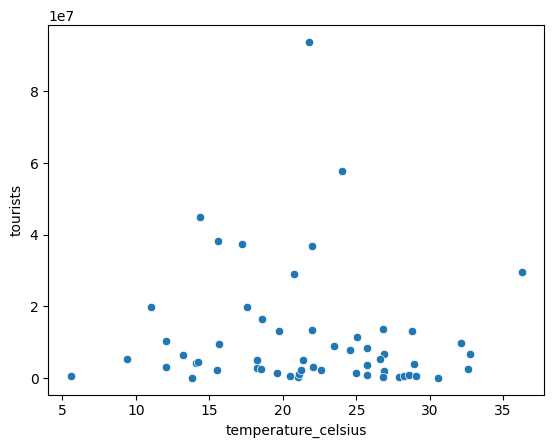

In [ ]:
#sanity check
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="temperature_celsius", y= "tourists")
plt.show()

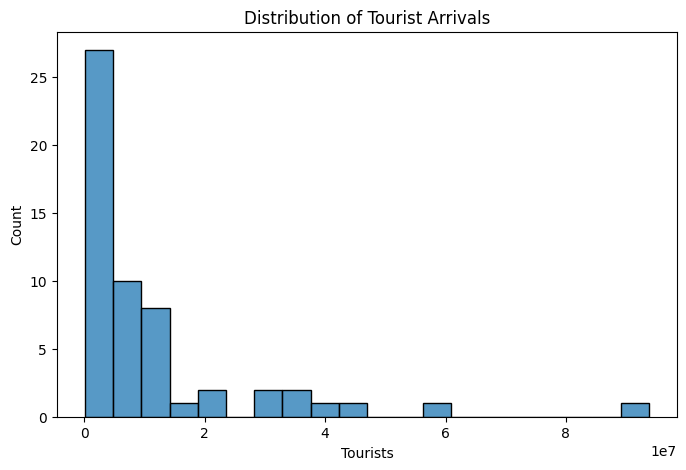

In [ ]:
#Ditribution of tourists
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["tourists"], bins=20)
plt.title("Distribution of Tourist Arrivals")
plt.xlabel("Tourists")
plt.show()

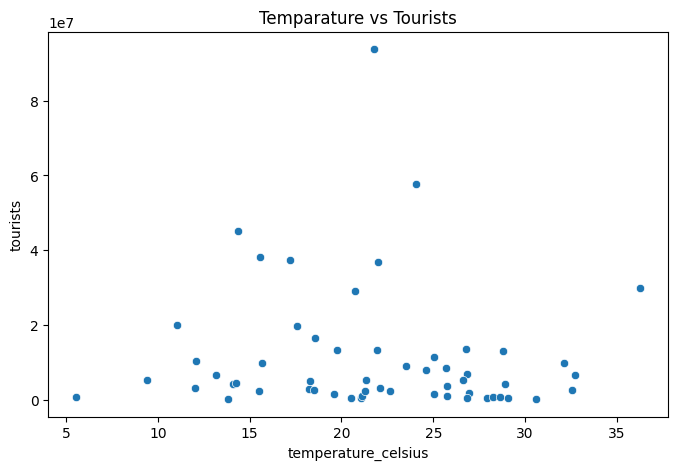

In [59]:
#Tourism vs Temp
plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = "temperature_celsius", y = "tourists")
plt.title("Temparature vs Tourists")
plt.show()

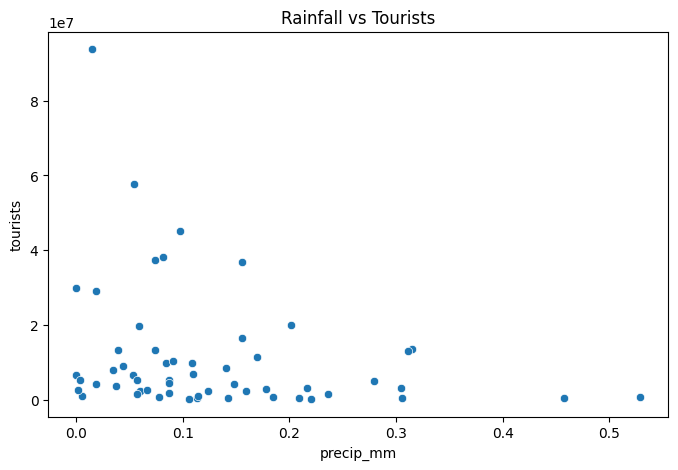

In [56]:
#toursium vs rainfall(precipitation)
plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = "precip_mm", y = "tourists")
plt.title("Rainfall vs Tourists")
plt.show()

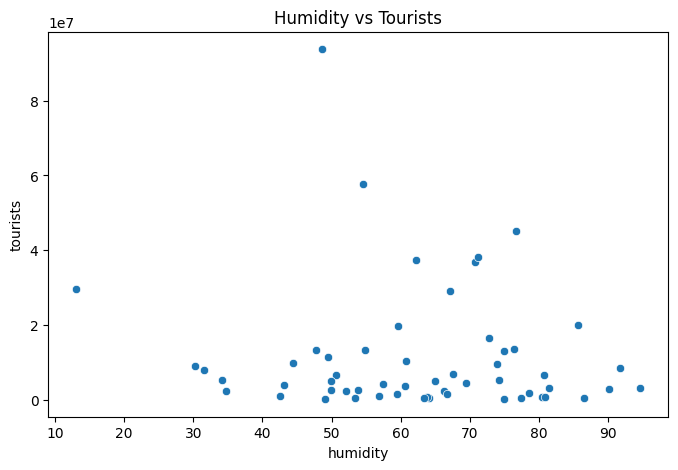

In [60]:
#tourists vs humidity
plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = "humidity", y = "tourists")
plt.title("Humidity vs Tourists")
plt.show()

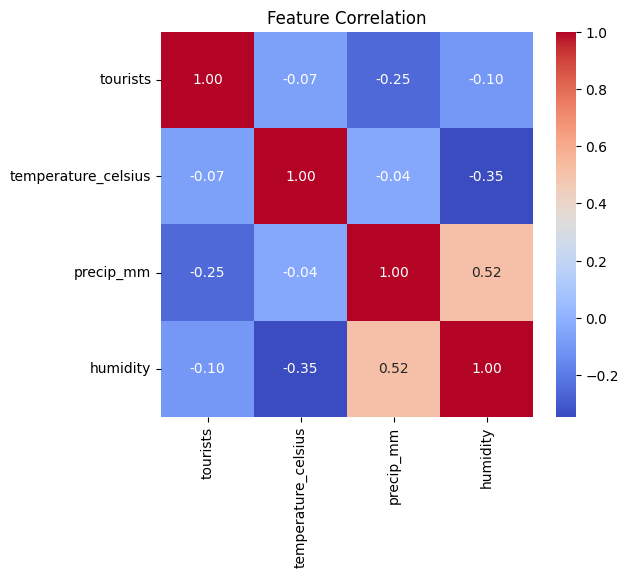

In [162]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df[["tourists","temperature_celsius","precip_mm","humidity"]].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlation")
plt.show()

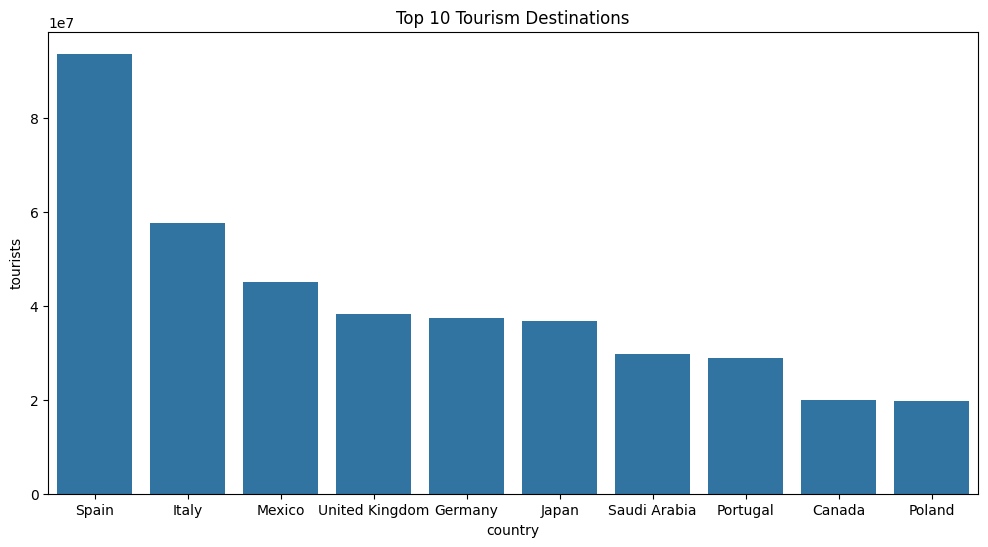

In [163]:
#Top countries
top = df.sort_values("tourists", ascending = False).head(10)

plt.figure(figsize = (12,6))
sns.barplot(data = top, x = "country", y = "tourists")
plt.title("Top 10 Tourism Destinations")
plt.show()

# ML Stage

In [101]:
#Define Features and Target variables
df.columns
X = df[["temperature_celsius", "precip_mm", "humidity"]]
y = df["tourists"]

In [102]:
#train, test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 123
)

In [103]:
#1st model: RandomForest
from sklearn.ensemble import RandomForestRegressor

model1 = RandomForestRegressor(random_state = 123)
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

In [121]:
#Evaluation
from sklearn.metrics import mean_squared_error, r2_score

mse1 = mean_squared_error(y_test, y_pred)
r2_1 = r2_score(y_test, y_pred)

print("MSE:", mse1)
print("R²:", r2_1)

MSE: 3.8881866280215243
R²: -0.013594814955079526


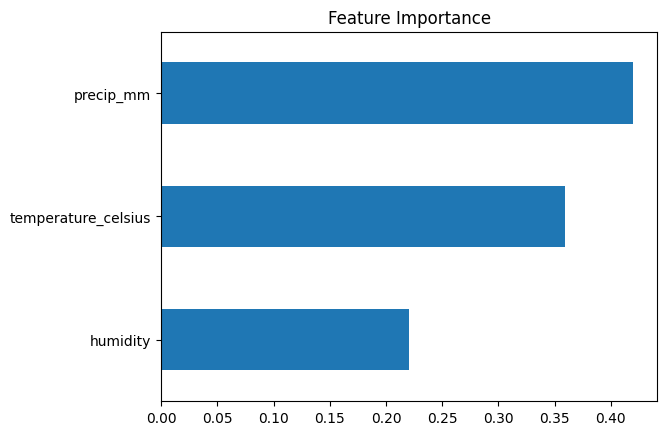

In [146]:
#Feature Importance
import pandas as pd
importance = pd.Series(
    model1.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [129]:
#Redifine 
import numpy as np

df["log_tourists"] = np.log1p(df["tourists"])

X1 = df[["temperature_celsius", "precip_mm", "humidity"]]
y1 = df["log_tourists"]

from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=123
)

In [139]:
#Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

#model dict
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=123),
    "Gradient Boosting": GradientBoostingRegressor(random_state=123)
}

results1 = []

for name, model in models.items():
    model.fit(X1_train, y1_train)
    preds = model.predict(X1_test)

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y1_test, preds)

    results1.append({
        "Model": name,
        "MSE": mse,
        "R2": r2
    })

results1_df = pd.DataFrame(results1).sort_values("R2", ascending=False)
results1_df

,Model,MSE,R2
1,Random Forest,3.608936,0.059202
0,Linear Regression,3.654853,0.047232
2,Gradient Boosting,5.051748,-0.316919


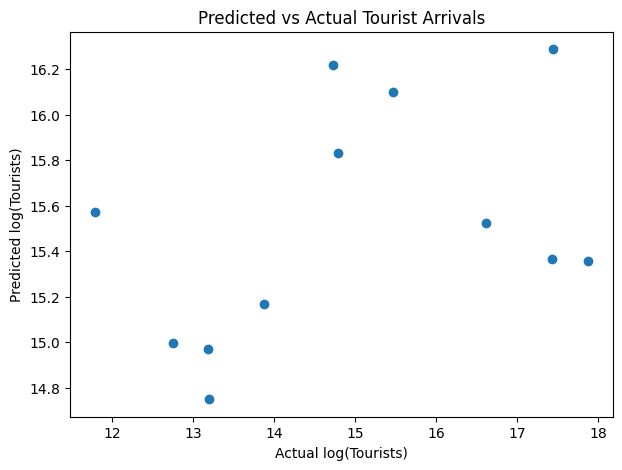

In [148]:
best_model1 = RandomForestRegressor(random_state=123)
best_model1.fit(X1_train, y1_train)
y_pred = best_model1.predict(X1_test)

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual log(Tourists)")
plt.ylabel("Predicted log(Tourists)")
plt.title("Predicted vs Actual Tourist Arrivals")
plt.show()

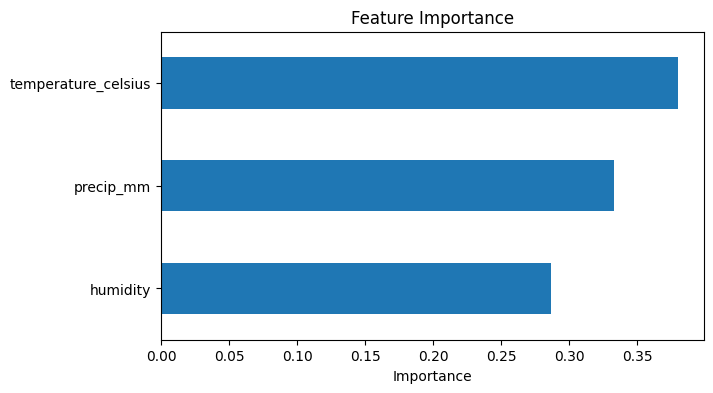

In [149]:
importance = pd.Series(
    best_model1.feature_importances_,
    index=X1.columns
).sort_values()

plt.figure(figsize=(7,4))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [150]:
#feature engineering
df["climate_index"] = df["temperature_celsius"] - 10 * df["precip_mm"]
df_model = pd.get_dummies(df, columns=["country"], drop_first=True)

X2 = df_model.drop(columns=["tourists", "log_tourists", "Year"])
y2 = df_model["log_tourists"]

from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=123
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

#model dict
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=123),
    "Gradient Boosting": GradientBoostingRegressor(random_state=123)
}

results2 = []

for name, model in models.items():
    model.fit(X2_train, y2_train)
    preds = model.predict(X2_test)

    mse = mean_squared_error(y2_test, preds)
    r2 = r2_score(y2_test, preds)

    results2.append({
        "Model": name,
        "MSE": mse,
        "R2": r2
    })

results2_df = pd.DataFrame(results2).sort_values("R2", ascending=False)
results2_df

,Model,MSE,R2
1,Random Forest,3.888187,-0.013595
2,Gradient Boosting,4.124414,-0.075176
0,Linear Regression,5.322462,-0.387490


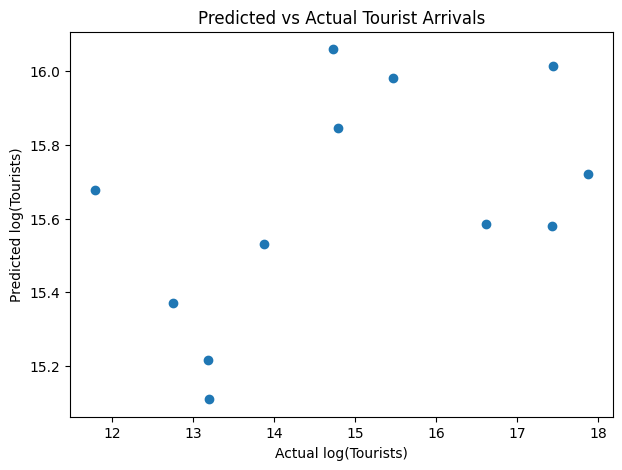

In [151]:
best_model2 = RandomForestRegressor(random_state=123)
best_model2.fit(X2_train, y2_train)
y_pred = best_model2.predict(X2_test)

plt.figure(figsize=(7,5))
plt.scatter(y2_test, y_pred)
plt.xlabel("Actual log(Tourists)")
plt.ylabel("Predicted log(Tourists)")
plt.title("Predicted vs Actual Tourist Arrivals")
plt.show()

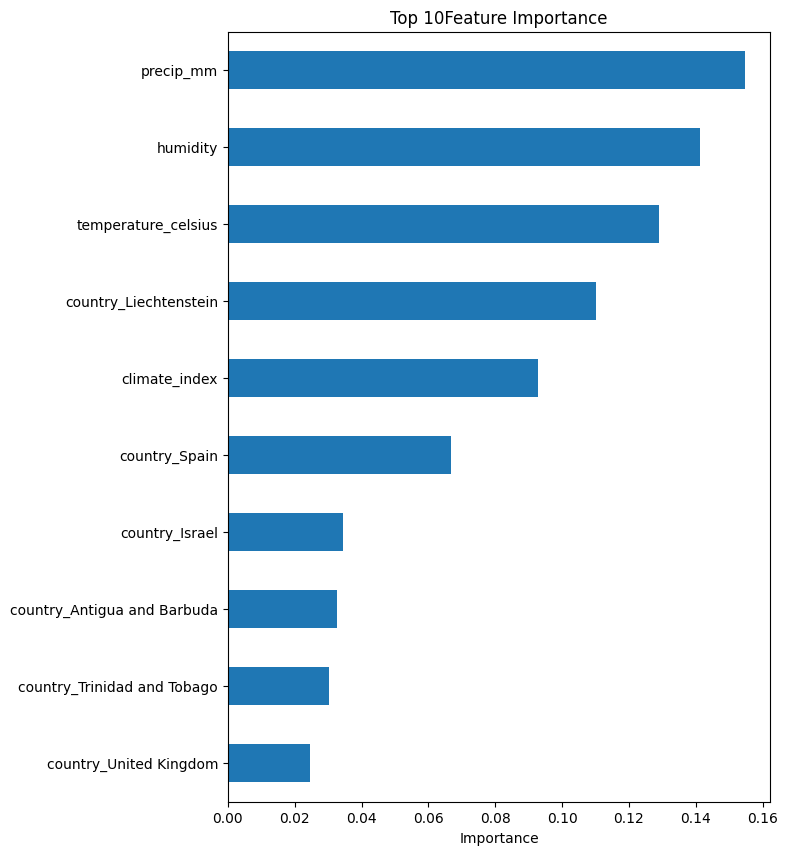

In [152]:
importance = pd.Series(
    best_model2.feature_importances_,
    index=X2.columns
).sort_values(ascending = False)

plt.figure(figsize=(7,10))
importance.head(10).plot(kind="barh")
plt.title("Top 10Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [159]:
#cv
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X1,
        y1,
        cv=5,
        scoring="r2"
    )
    
    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "Mean CV R2",
    ascending=False
)

cv_results_df.round(3)

,Model,Mean CV R2,Std CV R2
0,Linear Regression,-0.139,0.256
1,Random Forest,-0.411,0.233
2,Gradient Boosting,-0.872,0.662
